# 09 - Hedged Performance Attribution: A6 + Momentum + Beta Hedge

Detailed attribution of the best hedged strategy:
- **Stock Selection**: All6-EW
- **Portfolio Construction**: Momentum-weighted
- **Hedging**: Rolling 60m OLS beta vs MSCI EM

This notebook answers:
1. How does beta evolve over time? (60m and 36m rolling)
2. What does the alpha time series look like after hedging?
3. Rolling IR, tracking error, and hedged Sharpe
4. How does the strategy perform in up vs down markets?
5. TC sensitivity and break-even analysis

In [1]:
import sys
sys.path.insert(0, '..')

import os
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

from src.data_loader import load_benchmark, INDUSTRIES
from src.performance import (
    performance_table, plot_cumulative_returns, plot_drawdown,
    max_drawdown, drawdown_series,
)

DATA_DIR = '../data'
OUTPUT_DIR = '../output'
FIG_DIR = f'{OUTPUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

## 1. Strategy Overview

In [2]:
benchmark = load_benchmark(DATA_DIR)

# Load hedge details
hedge = pd.read_csv(f'{OUTPUT_DIR}/csv/exp5_hedged_a6_momentum.csv',
                     index_col=0, parse_dates=True)

# Load unhedged
a6_master = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_a6_lw60_returns.csv',
                         index_col=0, parse_dates=True)
unhedged = a6_master['Momentum']

# Load all betas
betas_all = pd.read_csv(f'{OUTPUT_DIR}/csv/exp5_betas.csv',
                         index_col=0, parse_dates=True)

# Load final performance
final_perf = pd.read_csv(f'{OUTPUT_DIR}/csv/exp5_final_performance.csv', index_col=0)

hedged_ret = hedge['hedged']
port_ret = hedge['portfolio']
beta_ts = hedge['beta']
bench_ret = hedge['benchmark']

common = hedged_ret.dropna().index

print('=' * 70)
print('  STRATEGY: A6-EW + Momentum + Beta Hedge')
print('=' * 70)
ann_ret = hedged_ret.mean() * 12
ann_vol = hedged_ret.std() * np.sqrt(12)
sharpe = ann_ret / ann_vol
mdd = max_drawdown(hedged_ret)

print(f'  Period:          {common.min():%Y-%m} to {common.max():%Y-%m} ({len(common)} months)')
print(f'  Ann. Alpha:      {ann_ret:.1%}')
print(f'  Ann. Vol:        {ann_vol:.1%}')
print(f'  Sharpe Ratio:    {sharpe:.3f}')
print(f'  Max Drawdown:    {mdd:.1%}')
print(f'  Total Return:    {(1+hedged_ret).prod()-1:.1%}')
print(f'  Hit Rate:        {(hedged_ret>0).mean():.1%}')
print()
print('  Unhedged comparison:')
uh = port_ret.loc[common]
print(f'    Ann. Return: {uh.mean()*12:.1%}, Vol: {uh.std()*np.sqrt(12):.1%}, '
      f'Sharpe: {uh.mean()*12/(uh.std()*np.sqrt(12)):.3f}')

Benchmark loaded: 289 months | 2001-05 to 2025-05
  STRATEGY: A6-EW + Momentum + Beta Hedge
  Period:          2019-02 to 2025-03 (74 months)
  Ann. Alpha:      8.9%
  Ann. Vol:        6.1%
  Sharpe Ratio:    1.467
  Max Drawdown:    7.2%
  Total Return:    70.8%
  Hit Rate:        63.5%

  Unhedged comparison:
    Ann. Return: 11.0%, Vol: 17.1%, Sharpe: 0.644


## 2. Beta Dynamics

Beta measures the portfolio's sensitivity to MSCI EM. A beta of 0.9 means
for every 1% move in MSCI EM, the portfolio moves ~0.9%. The hedge removes
this by shorting `beta * MSCI EM` each month.

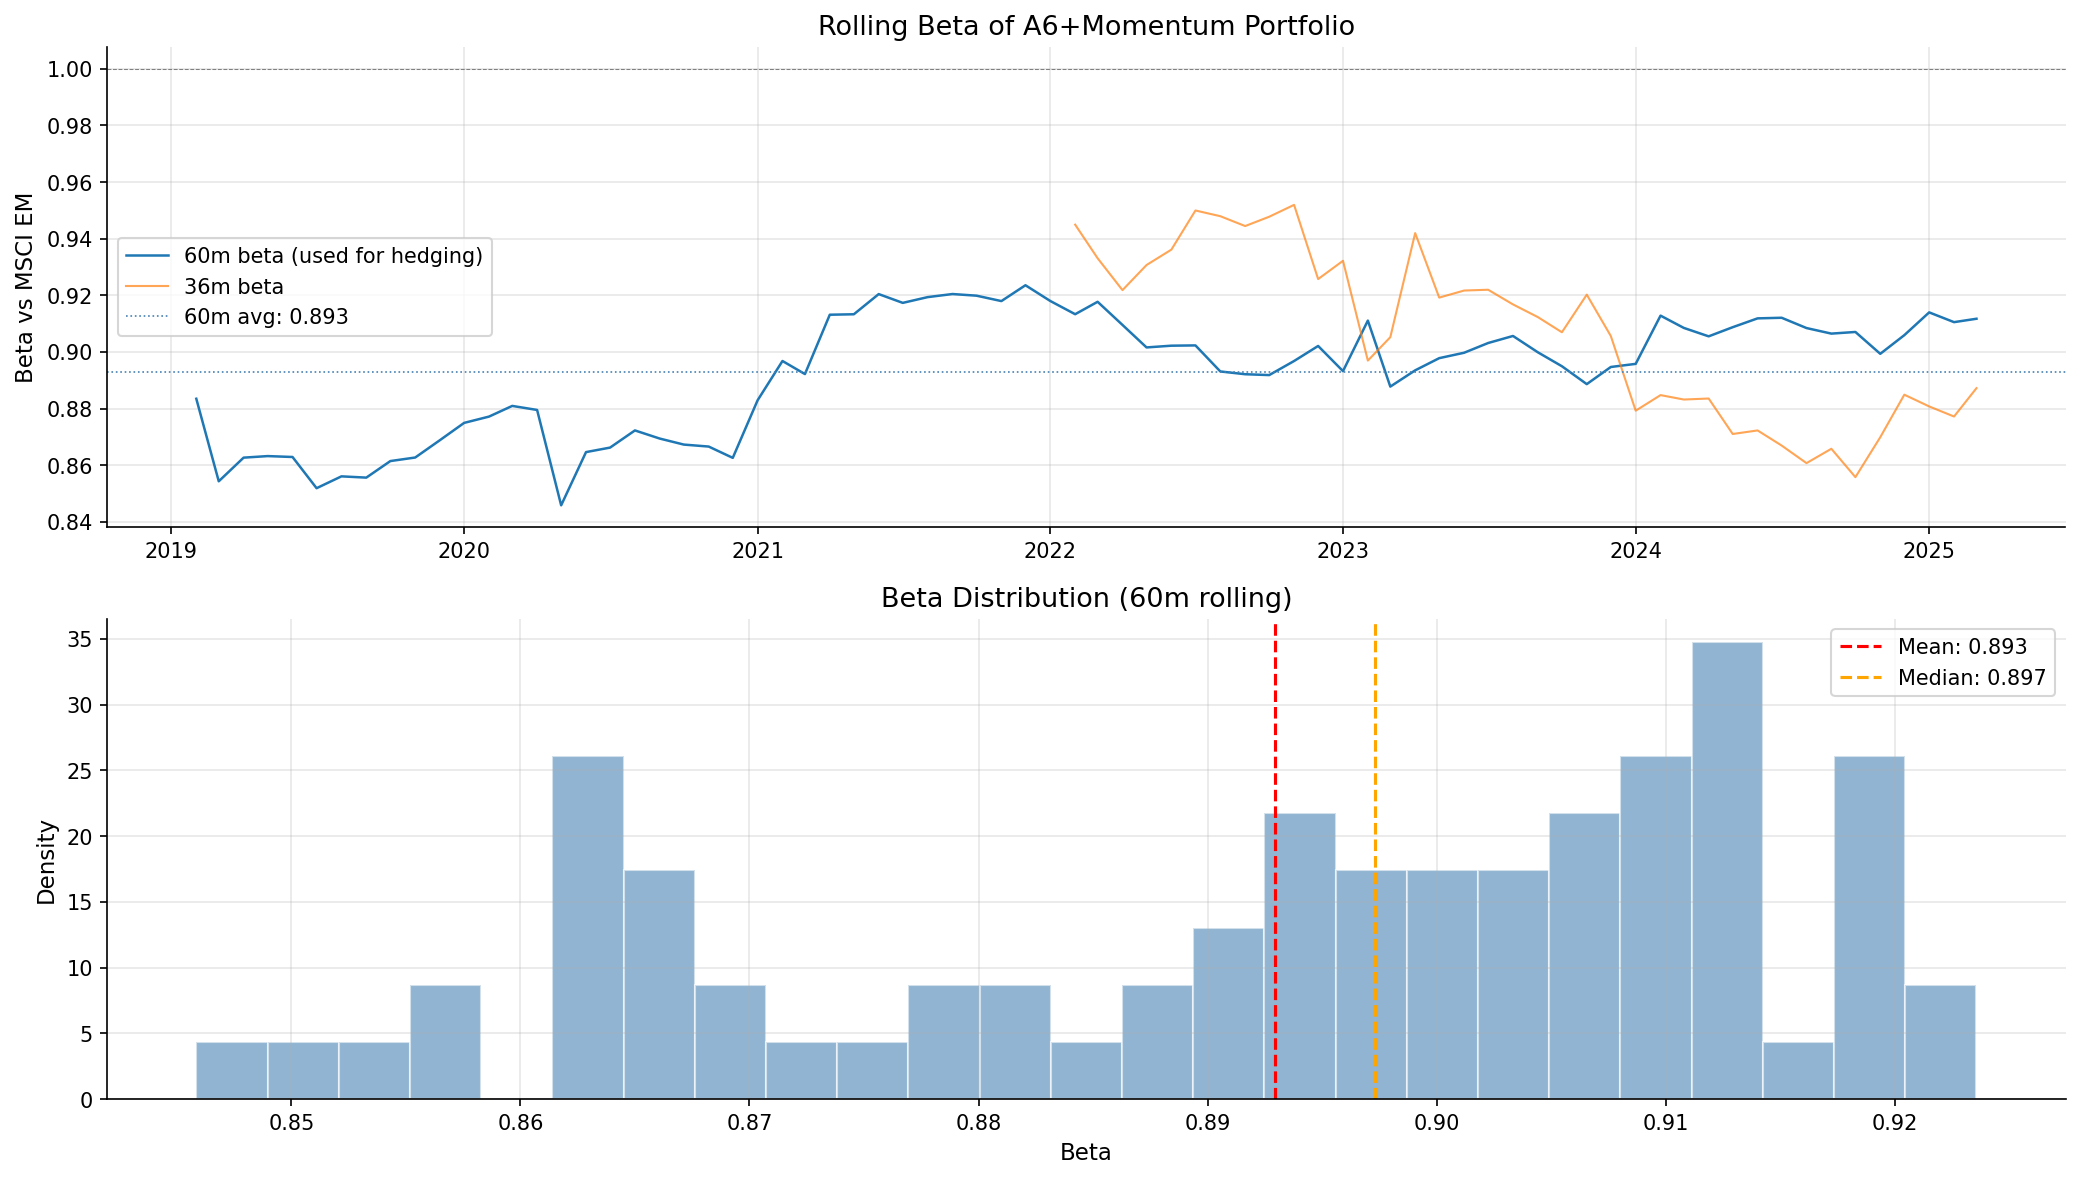

Saved: nb09_beta_dynamics.pdf

60m Beta: mean=0.893, std=0.021, min=0.846, max=0.924
36m Beta: mean=0.907, std=0.030


In [3]:
def rolling_beta(port, bench, window):
    common = port.dropna().index.intersection(bench.dropna().index).sort_values()
    betas = []
    for i in range(window, len(common)):
        y = port.loc[common[i-window:i]].values
        x = bench.loc[common[i-window:i]].values
        cov_xy = np.cov(y, x, ddof=1)
        b = cov_xy[0,1] / cov_xy[1,1] if cov_xy[1,1] > 0 else 0.0
        betas.append((common[i], b))
    return pd.Series(dict(betas))

beta_60 = beta_ts.dropna()
beta_36 = rolling_beta(port_ret, bench_ret, 36)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(beta_60.index, beta_60.values, linewidth=1.2, label='60m beta (used for hedging)')
ax.plot(beta_36.index, beta_36.values, linewidth=1.0, alpha=0.7, label='36m beta')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.5)
ax.axhline(beta_60.mean(), color='steelblue', linestyle=':', linewidth=0.8,
           label=f'60m avg: {beta_60.mean():.3f}')
ax.set_ylabel('Beta vs MSCI EM')
ax.set_title('Rolling Beta of A6+Momentum Portfolio')
ax.legend()

ax = axes[1]
ax.hist(beta_60.values, bins=25, alpha=0.6, color='steelblue', edgecolor='white', density=True)
ax.axvline(beta_60.mean(), color='red', linestyle='--', label=f'Mean: {beta_60.mean():.3f}')
ax.axvline(beta_60.median(), color='orange', linestyle='--', label=f'Median: {beta_60.median():.3f}')
ax.set_xlabel('Beta')
ax.set_ylabel('Density')
ax.set_title('Beta Distribution (60m rolling)')
ax.legend()

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_beta_dynamics.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_beta_dynamics.pdf')
print(f'\n60m Beta: mean={beta_60.mean():.3f}, std={beta_60.std():.3f}, '
      f'min={beta_60.min():.3f}, max={beta_60.max():.3f}')
print(f'36m Beta: mean={beta_36.mean():.3f}, std={beta_36.std():.3f}')

## 3. Alpha Time Series

After hedging, the return = alpha (pure industry-specific signal,
market risk removed). This section shows the alpha stream over time.

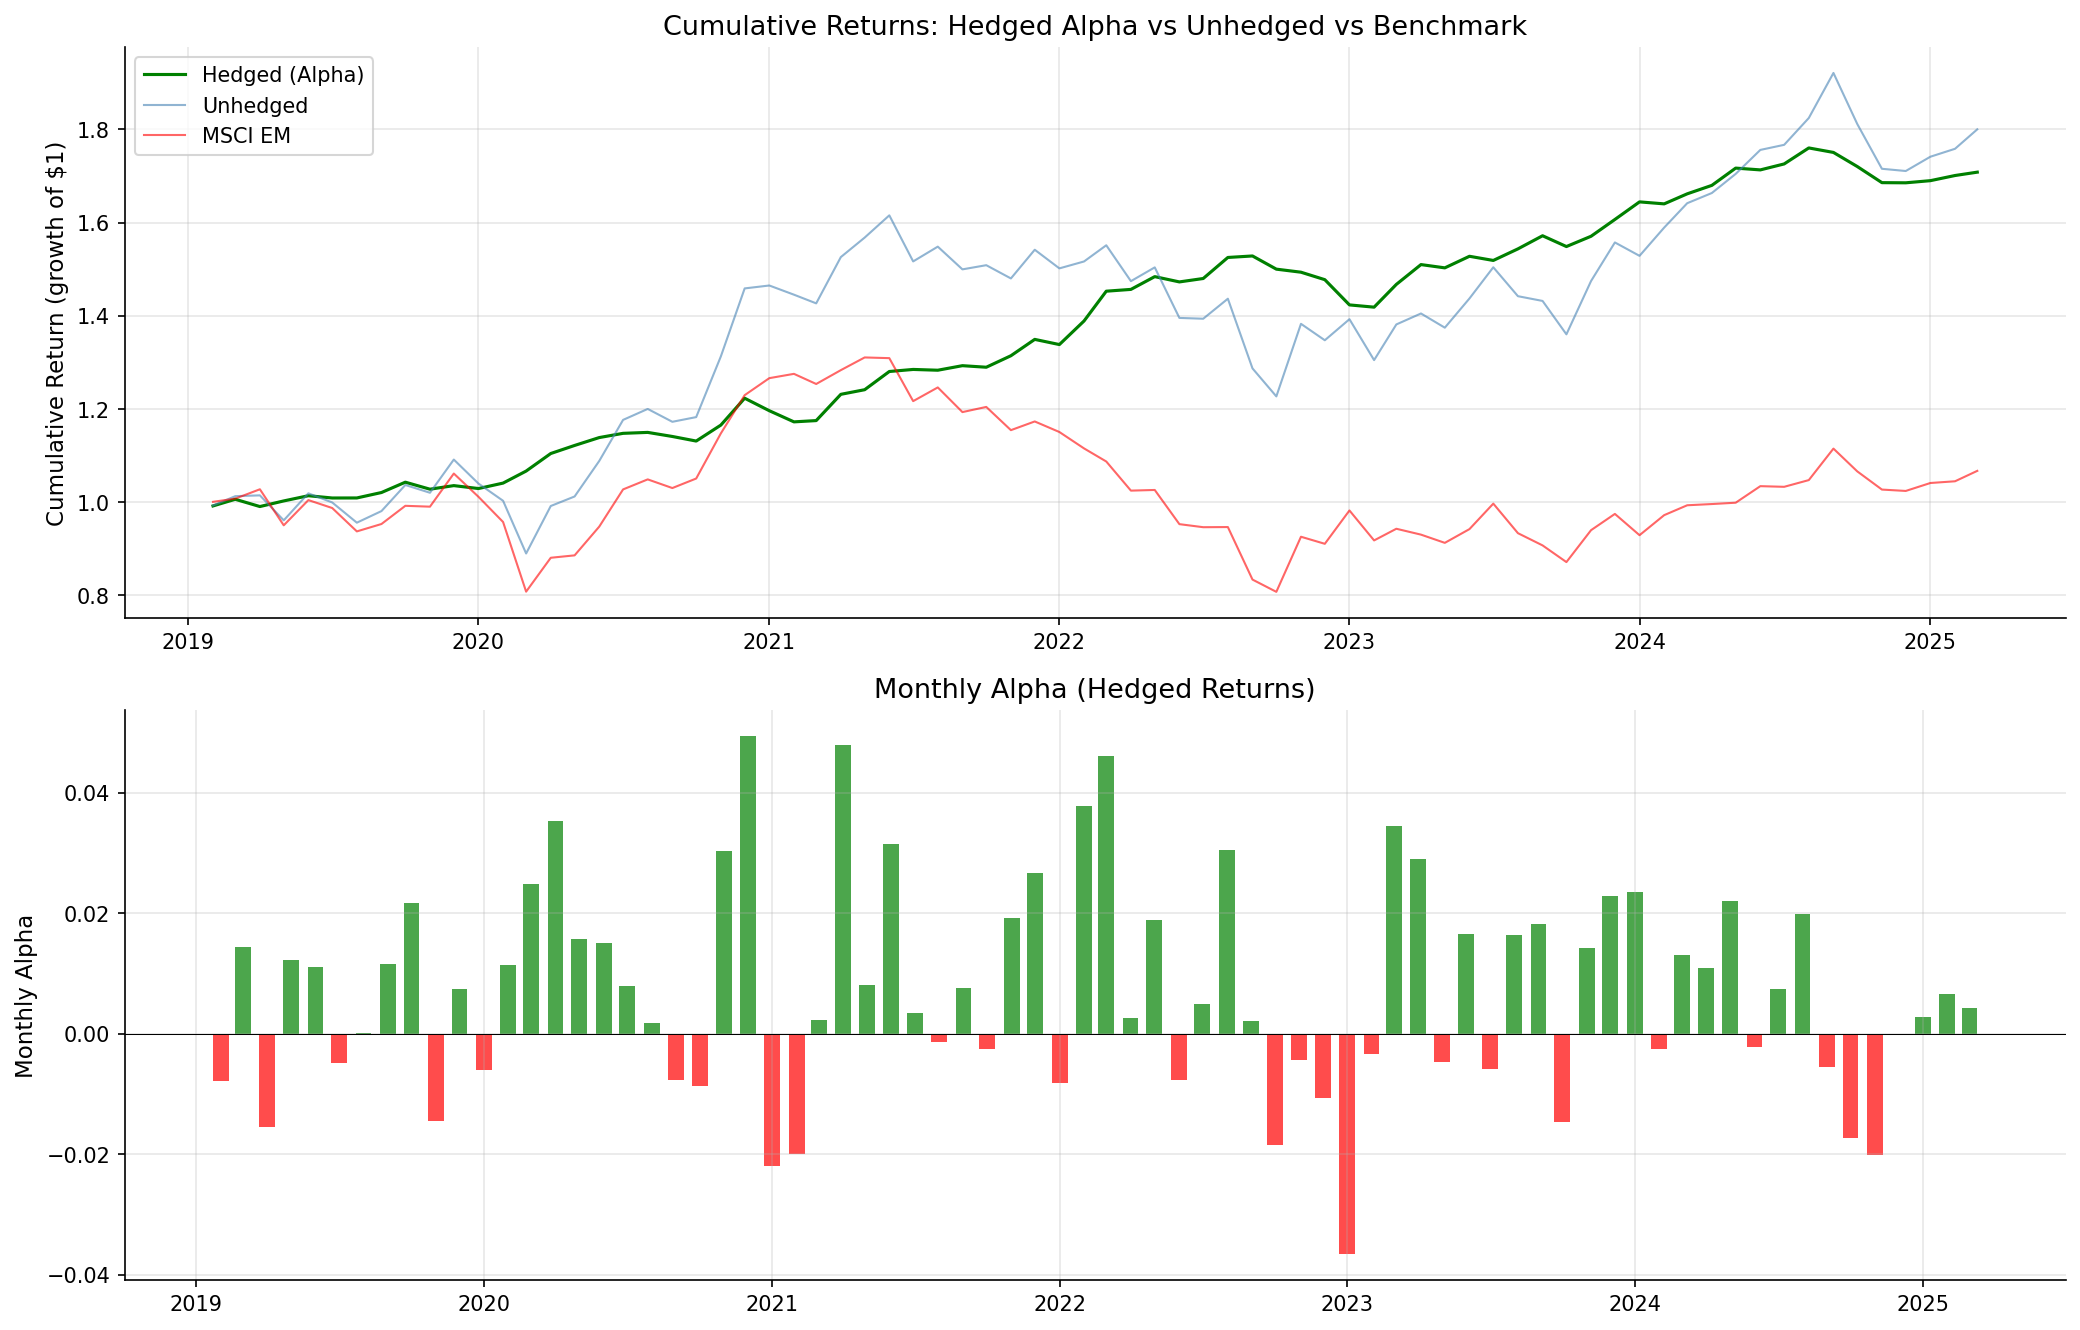

Saved: nb09_alpha_timeseries.pdf


In [4]:
# Cumulative alpha
cum_alpha = (1 + hedged_ret).cumprod()
cum_port = (1 + port_ret.loc[common]).cumprod()
cum_bench = (1 + bench_ret.loc[common]).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(cum_alpha.index, cum_alpha.values, linewidth=1.5, color='green', label='Hedged (Alpha)')
ax.plot(cum_port.index, cum_port.values, linewidth=1.0, alpha=0.6, color='steelblue', label='Unhedged')
ax.plot(cum_bench.index, cum_bench.values, linewidth=1.0, alpha=0.6, color='red', label='MSCI EM')
ax.set_ylabel('Cumulative Return (growth of $1)')
ax.set_title('Cumulative Returns: Hedged Alpha vs Unhedged vs Benchmark')
ax.legend()

ax = axes[1]
colors = ['green' if r > 0 else 'red' for r in hedged_ret.values]
ax.bar(hedged_ret.index, hedged_ret.values, width=20, color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Monthly Alpha')
ax.set_title('Monthly Alpha (Hedged Returns)')

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_alpha_timeseries.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_alpha_timeseries.pdf')

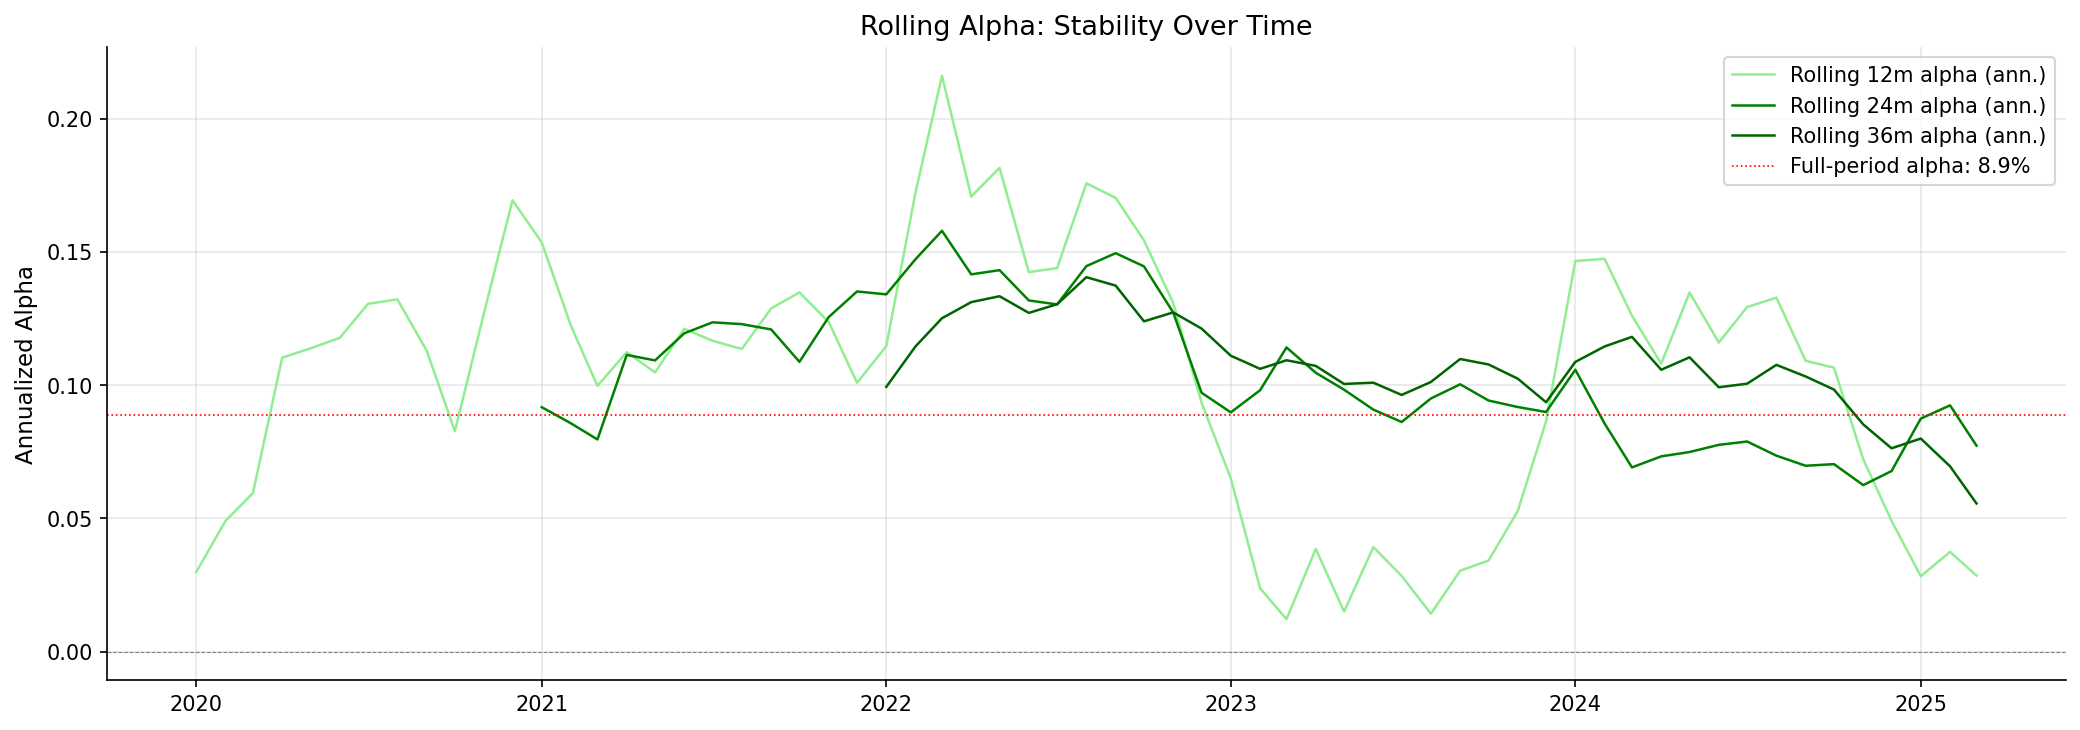

Saved: nb09_rolling_alpha.pdf


In [5]:
# Rolling alpha (annualized)
def rolling_ann_ret(s, window):
    return s.rolling(window).mean() * 12

fig, ax = plt.subplots(figsize=(14, 5))
for w, lbl, clr in [(12, '12m', 'lightgreen'), (24, '24m', 'green'), (36, '36m', 'darkgreen')]:
    roll = rolling_ann_ret(hedged_ret, w)
    ax.plot(roll.index, roll.values, linewidth=1.2, color=clr, label=f'Rolling {lbl} alpha (ann.)')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.axhline(hedged_ret.mean()*12, color='red', linestyle=':', linewidth=0.8,
           label=f'Full-period alpha: {hedged_ret.mean()*12:.1%}')
ax.set_ylabel('Annualized Alpha')
ax.set_title('Rolling Alpha: Stability Over Time')
ax.legend()
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_rolling_alpha.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_rolling_alpha.pdf')

In [6]:
# Alpha by year
annual = hedged_ret.groupby(hedged_ret.index.year)
print('=== Alpha by Year ===')
print(f'{"Year":>6s}  {"Alpha (ann.)":>12s}  {"Vol":>8s}  {"Sharpe":>8s}  {"Hit%":>6s}  {"Months":>7s}')
print('-' * 55)
for yr, grp in annual:
    if len(grp) < 3:
        continue
    ann = grp.mean() * 12
    vol = grp.std() * np.sqrt(12)
    sr = ann / vol if vol > 0 else 0
    hr = (grp > 0).mean()
    print(f'{yr:6d}  {ann:12.1%}  {vol:8.1%}  {sr:8.2f}  {hr:6.0%}  {len(grp):7d}')

=== Alpha by Year ===
  Year  Alpha (ann.)       Vol    Sharpe    Hit%   Months
-------------------------------------------------------
  2019          3.9%      4.3%      0.91     64%       11
  2020         16.9%      6.3%      2.68     75%       12
  2021         10.1%      7.0%      1.43     67%       12
  2022          9.3%      7.2%      1.30     58%       12
  2023          8.6%      7.1%      1.22     58%       12
  2024          4.9%      5.0%      0.97     50%       12
  2025          5.4%      0.7%      8.13    100%        3


## 4. Tracking Error and Information Ratio

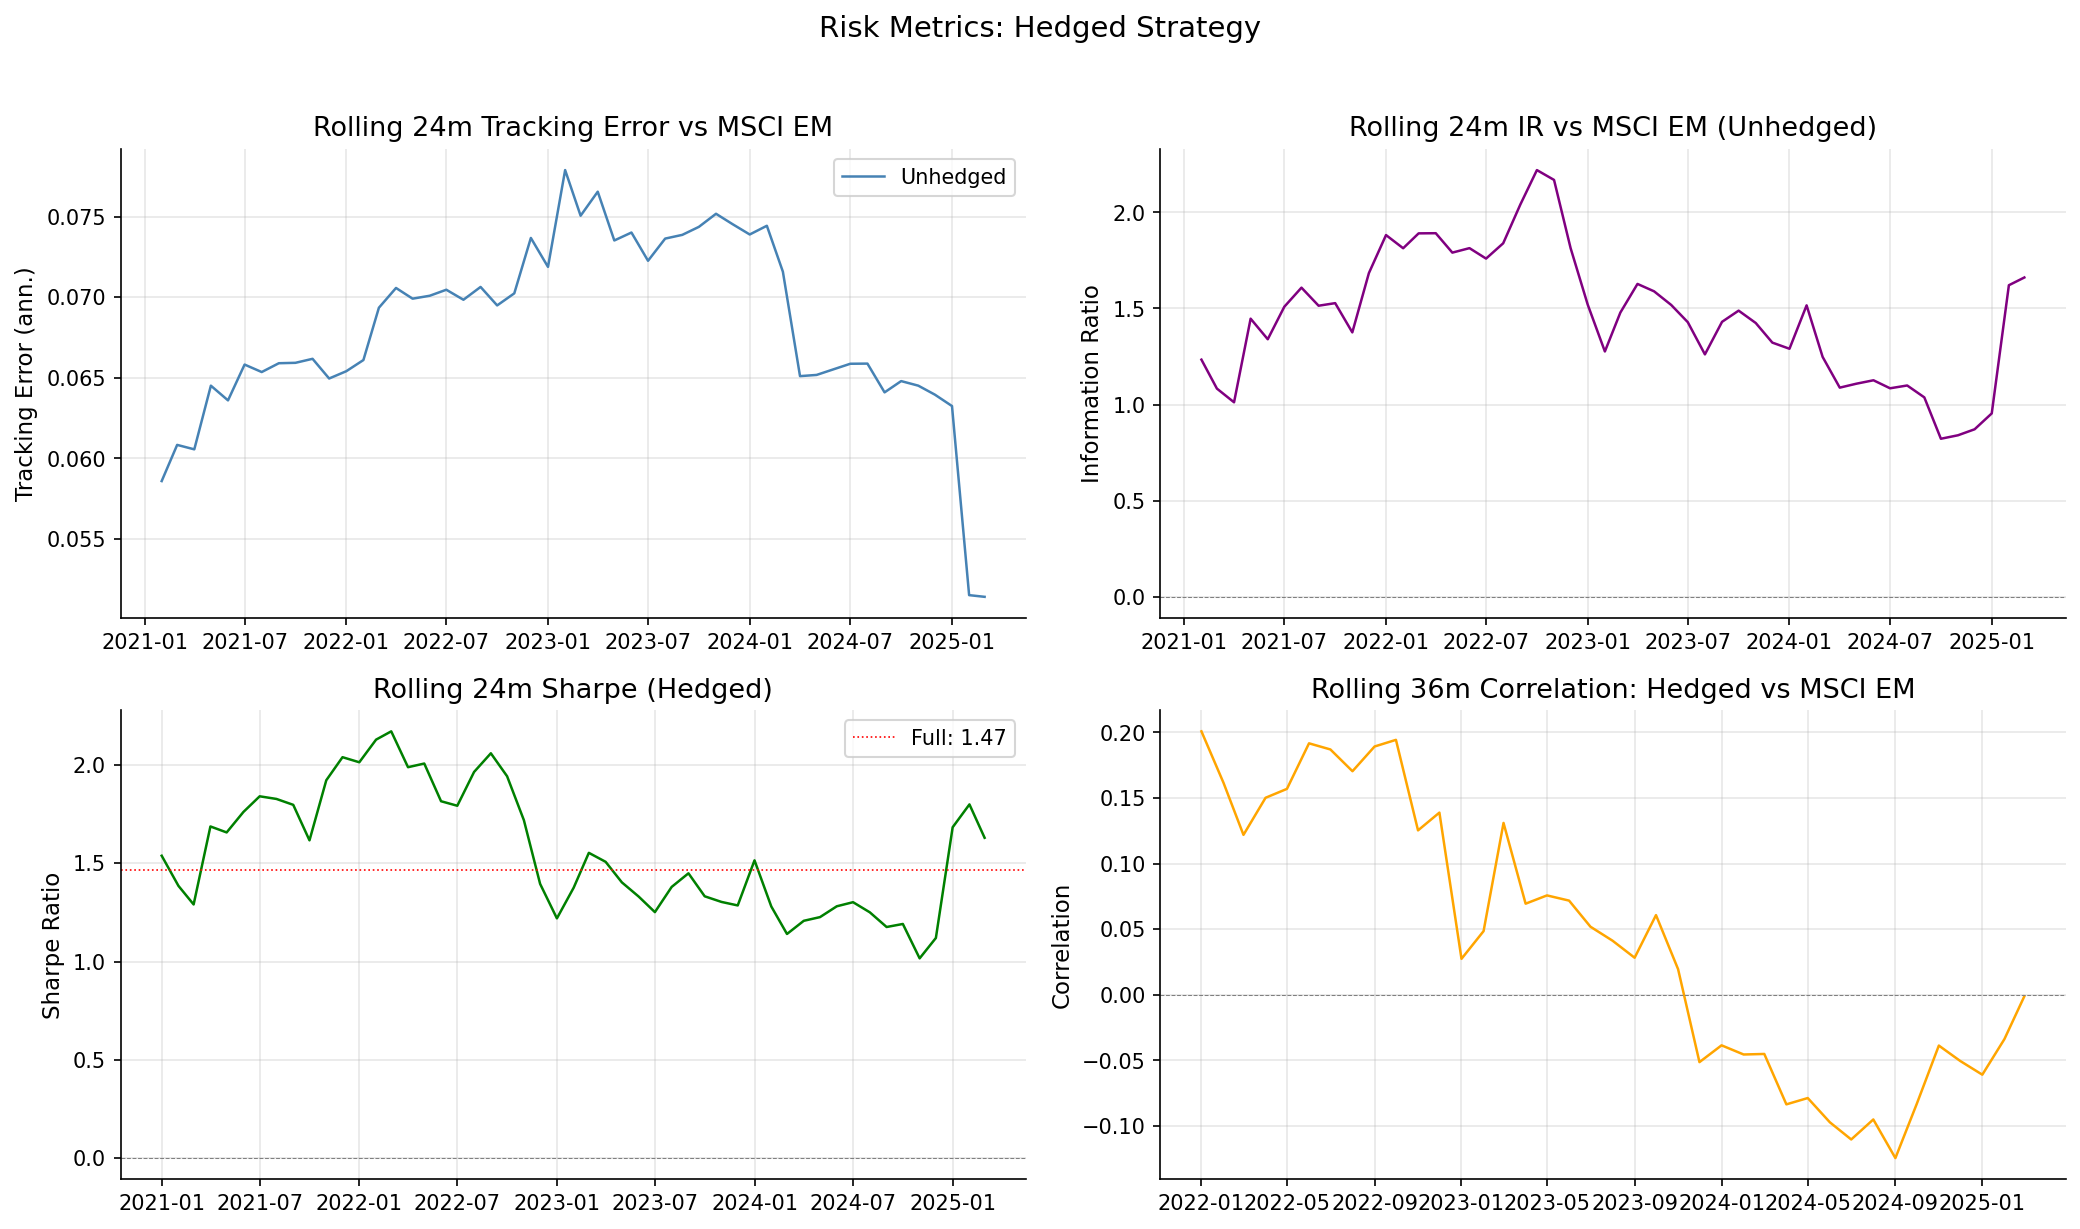

Saved: nb09_risk_metrics.pdf

Full-period stats:
  Unhedged TE: 6.2%, IR: 1.358
  Hedged vol: 6.1%
  Hedged-benchmark corr: 0.070


In [7]:
def rolling_te(port, bench, window):
    c = port.dropna().index.intersection(bench.dropna().index).sort_values()
    te_list = []
    for i in range(window, len(c)):
        excess = port.loc[c[i-window:i]] - bench.loc[c[i-window:i]]
        te_list.append((c[i], excess.std() * np.sqrt(12)))
    return pd.Series(dict(te_list))

def rolling_ir(port, bench, window):
    c = port.dropna().index.intersection(bench.dropna().index).sort_values()
    ir_list = []
    for i in range(window, len(c)):
        excess = port.loc[c[i-window:i]] - bench.loc[c[i-window:i]]
        te = excess.std() * np.sqrt(12)
        ann_excess = excess.mean() * 12
        ir_list.append((c[i], ann_excess / te if te > 0 else 0.0))
    return pd.Series(dict(ir_list))

# Unhedged TE/IR
te_uh_24 = rolling_te(port_ret, benchmark, 24)
ir_uh_24 = rolling_ir(port_ret, benchmark, 24)

# Hedged TE/IR
te_h_24 = rolling_te(hedged_ret, pd.Series(0, index=hedged_ret.index), 24)
ir_h_24 = rolling_ir(port_ret, benchmark, 24)

# Hedged rolling Sharpe
h_sharpe_24 = hedged_ret.rolling(24).apply(
    lambda x: x.mean()*12 / (x.std()*np.sqrt(12)) if x.std()>0 else 0
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ax = axes[0, 0]
ax.plot(te_uh_24.index, te_uh_24.values, linewidth=1.2, label='Unhedged', color='steelblue')
ax.set_ylabel('Tracking Error (ann.)')
ax.set_title('Rolling 24m Tracking Error vs MSCI EM')
ax.legend()

ax = axes[0, 1]
ax.plot(ir_uh_24.index, ir_uh_24.values, linewidth=1.2, color='purple')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.set_ylabel('Information Ratio')
ax.set_title('Rolling 24m IR vs MSCI EM (Unhedged)')

ax = axes[1, 0]
ax.plot(h_sharpe_24.index, h_sharpe_24.values, linewidth=1.2, color='green')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.axhline(sharpe, color='red', linestyle=':', linewidth=0.8, label=f'Full: {sharpe:.2f}')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Rolling 24m Sharpe (Hedged)')
ax.legend()

ax = axes[1, 1]
# Rolling 36m correlation of hedged returns with benchmark
rolling_corr = hedged_ret.rolling(36).corr(bench_ret.reindex(hedged_ret.index))
ax.plot(rolling_corr.index, rolling_corr.values, linewidth=1.2, color='orange')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.set_ylabel('Correlation')
ax.set_title('Rolling 36m Correlation: Hedged vs MSCI EM')

fig.suptitle('Risk Metrics: Hedged Strategy', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_risk_metrics.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_risk_metrics.pdf')
print(f'\nFull-period stats:')
excess = port_ret.loc[common] - benchmark.loc[common]
te_full = excess.std() * np.sqrt(12)
ir_full = excess.mean() * 12 / te_full
print(f'  Unhedged TE: {te_full:.1%}, IR: {ir_full:.3f}')
print(f'  Hedged vol: {hedged_ret.std()*np.sqrt(12):.1%}')
print(f'  Hedged-benchmark corr: {hedged_ret.corr(bench_ret.reindex(hedged_ret.index)):.3f}')

## 5. Unhedged vs Hedged Comparison

In [8]:
# Side-by-side comparison
perf_compare = performance_table({
    'MSCI EM': benchmark.loc[common],
    'A6+Momentum (unhedged)': port_ret.loc[common],
    'A6+Momentum (hedged)': hedged_ret,
}, benchmark=benchmark)

print('=== Unhedged vs Hedged ===')
print(perf_compare[['Ann. Mean','Ann. Std','Sharpe','IR','Max DD','% Positive']].round(4).to_string())

=== Unhedged vs Hedged ===
                        Ann. Mean  Ann. Std  Sharpe      IR  Max DD  % Positive
Strategy                                                                       
MSCI EM                    0.0258    0.1752  0.1474     NaN  0.3837      0.5541
A6+Momentum (unhedged)     0.1100    0.1707  0.6442  1.3576  0.2404      0.5946
A6+Momentum (hedged)       0.0890    0.0607  1.4666  0.3483  0.0719      0.6351


=== Volatility Decomposition ===
  Total Vol (unhedged):     17.1%
  Systematic (beta x EM):   15.6% (92% of total)
  Idiosyncratic (alpha):    6.8% (40% of total)
  Hedged Vol (actual):      6.1%
  Average Beta:             0.893


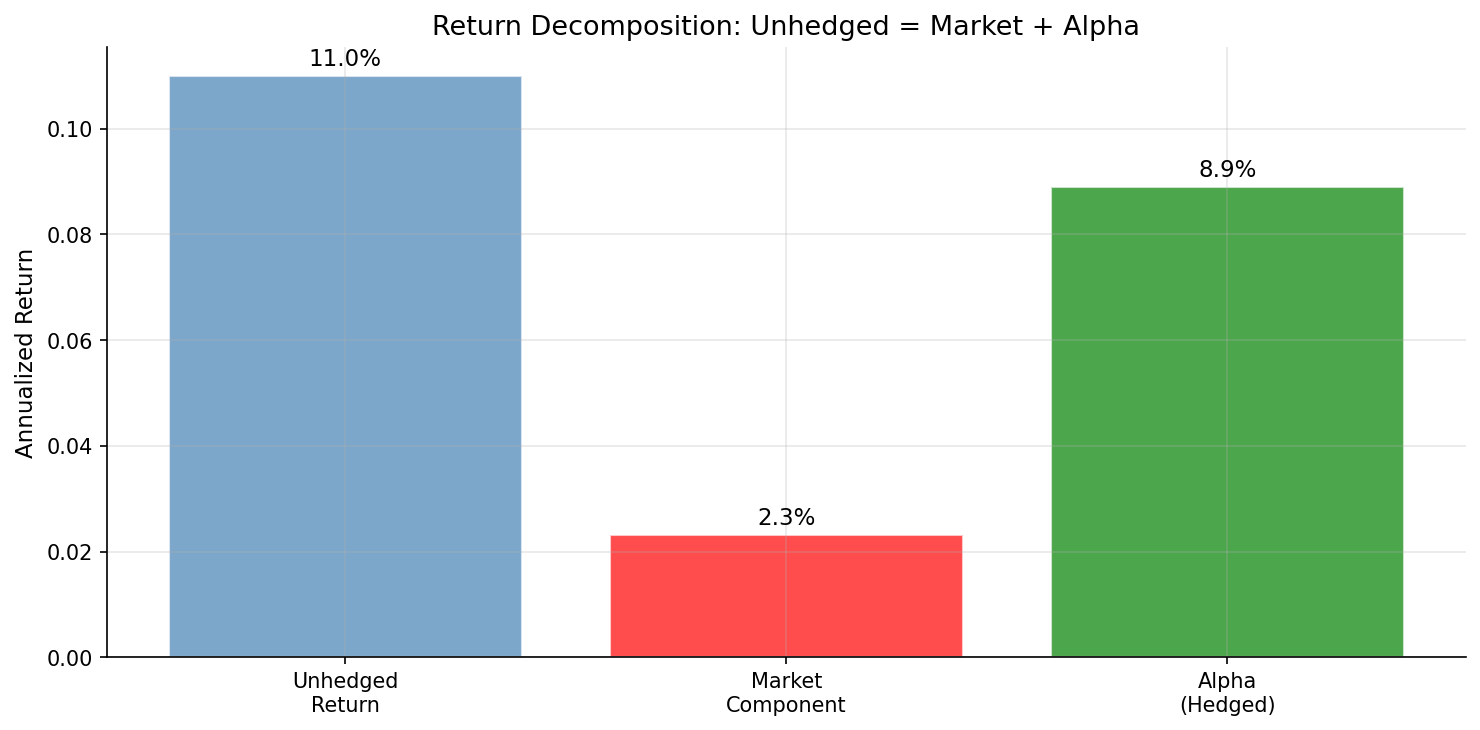

Saved: nb09_return_waterfall.pdf


In [9]:
# Volatility decomposition: systematic vs idiosyncratic
avg_beta = beta_ts.dropna().mean()
bench_vol = benchmark.loc[common].std() * np.sqrt(12)
total_vol = port_ret.loc[common].std() * np.sqrt(12)
systematic_vol = avg_beta * bench_vol
idio_vol = np.sqrt(total_vol**2 - systematic_vol**2) if total_vol > systematic_vol else 0

print('=== Volatility Decomposition ===')
print(f'  Total Vol (unhedged):     {total_vol:.1%}')
print(f'  Systematic (beta x EM):   {systematic_vol:.1%} ({systematic_vol/total_vol:.0%} of total)')
print(f'  Idiosyncratic (alpha):    {idio_vol:.1%} ({idio_vol/total_vol:.0%} of total)')
print(f'  Hedged Vol (actual):      {hedged_ret.std()*np.sqrt(12):.1%}')
print(f'  Average Beta:             {avg_beta:.3f}')

# Waterfall-style chart
fig, ax = plt.subplots(figsize=(10, 5))
labels = ['Unhedged\nReturn', 'Market\nComponent', 'Alpha\n(Hedged)']
uh_ret = port_ret.loc[common].mean() * 12
mkt_comp = avg_beta * benchmark.loc[common].mean() * 12
alpha_ret = hedged_ret.mean() * 12
values = [uh_ret, -mkt_comp, alpha_ret]
bottoms = [0, uh_ret, 0]
colors = ['steelblue', 'red', 'green']
bars = ax.bar(labels, [uh_ret, mkt_comp, alpha_ret], color=colors, alpha=0.7, edgecolor='white')
for bar, val in zip(bars, [uh_ret, mkt_comp, alpha_ret]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.1%}', ha='center', fontsize=11)
ax.set_ylabel('Annualized Return')
ax.set_title('Return Decomposition: Unhedged = Market + Alpha')
ax.axhline(0, color='black', linewidth=0.5)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_return_waterfall.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_return_waterfall.pdf')

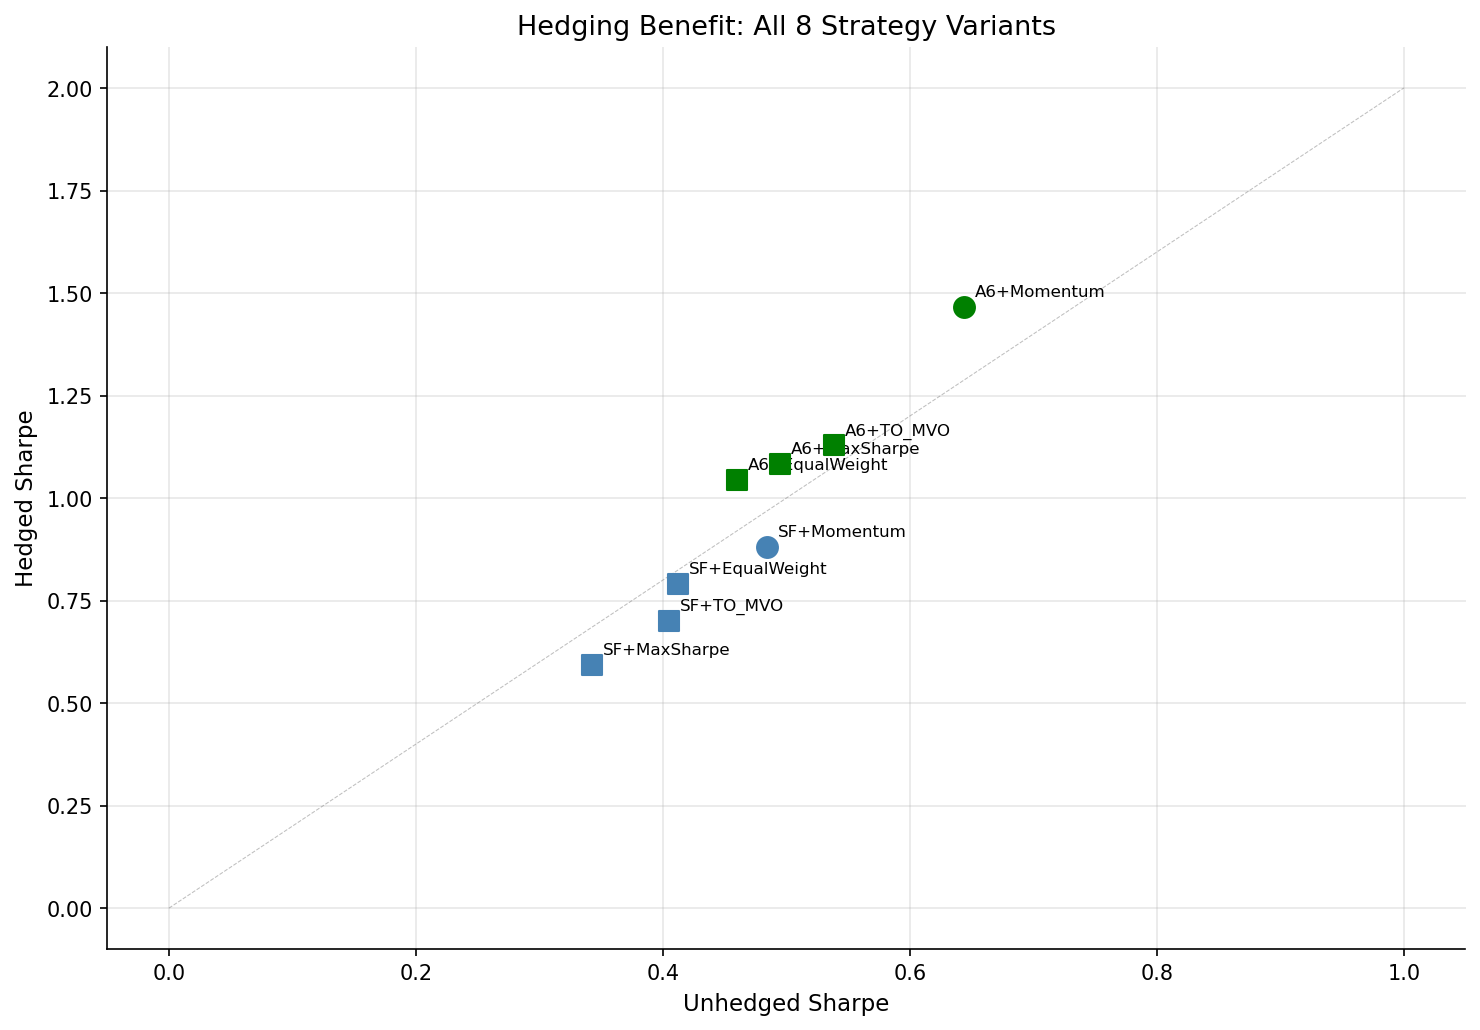

Saved: nb09_scatter.pdf


In [10]:
# Risk-return scatter of all 8 strategies
fig, ax = plt.subplots(figsize=(10, 7))
strategies = ['SF+EqualWeight', 'SF+Momentum', 'SF+TO_MVO', 'SF+MaxSharpe',
              'A6+EqualWeight', 'A6+Momentum', 'A6+TO_MVO', 'A6+MaxSharpe']
for strat in strategies:
    uh_name = f'{strat} (unhedged)'
    h_name = f'{strat} (hedged)'
    if uh_name in final_perf.index and h_name in final_perf.index:
        uh_sr = final_perf.loc[uh_name, 'Sharpe']
        h_sr = final_perf.loc[h_name, 'Sharpe']
        color = 'green' if 'A6' in strat else 'steelblue'
        marker = 'o' if 'Momentum' in strat else 's'
        ax.scatter(uh_sr, h_sr, s=100, color=color, marker=marker, zorder=5)
        ax.annotate(strat, (uh_sr, h_sr), fontsize=8,
                    xytext=(5, 5), textcoords='offset points')

ax.plot([0, 1], [0, 2], 'grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Unhedged Sharpe')
ax.set_ylabel('Hedged Sharpe')
ax.set_title('Hedging Benefit: All 8 Strategy Variants')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_scatter.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_scatter.pdf')

## 6. Transaction Cost Deep Dive

Break-even for Sharpe=1.0: 127 bps round-trip TC


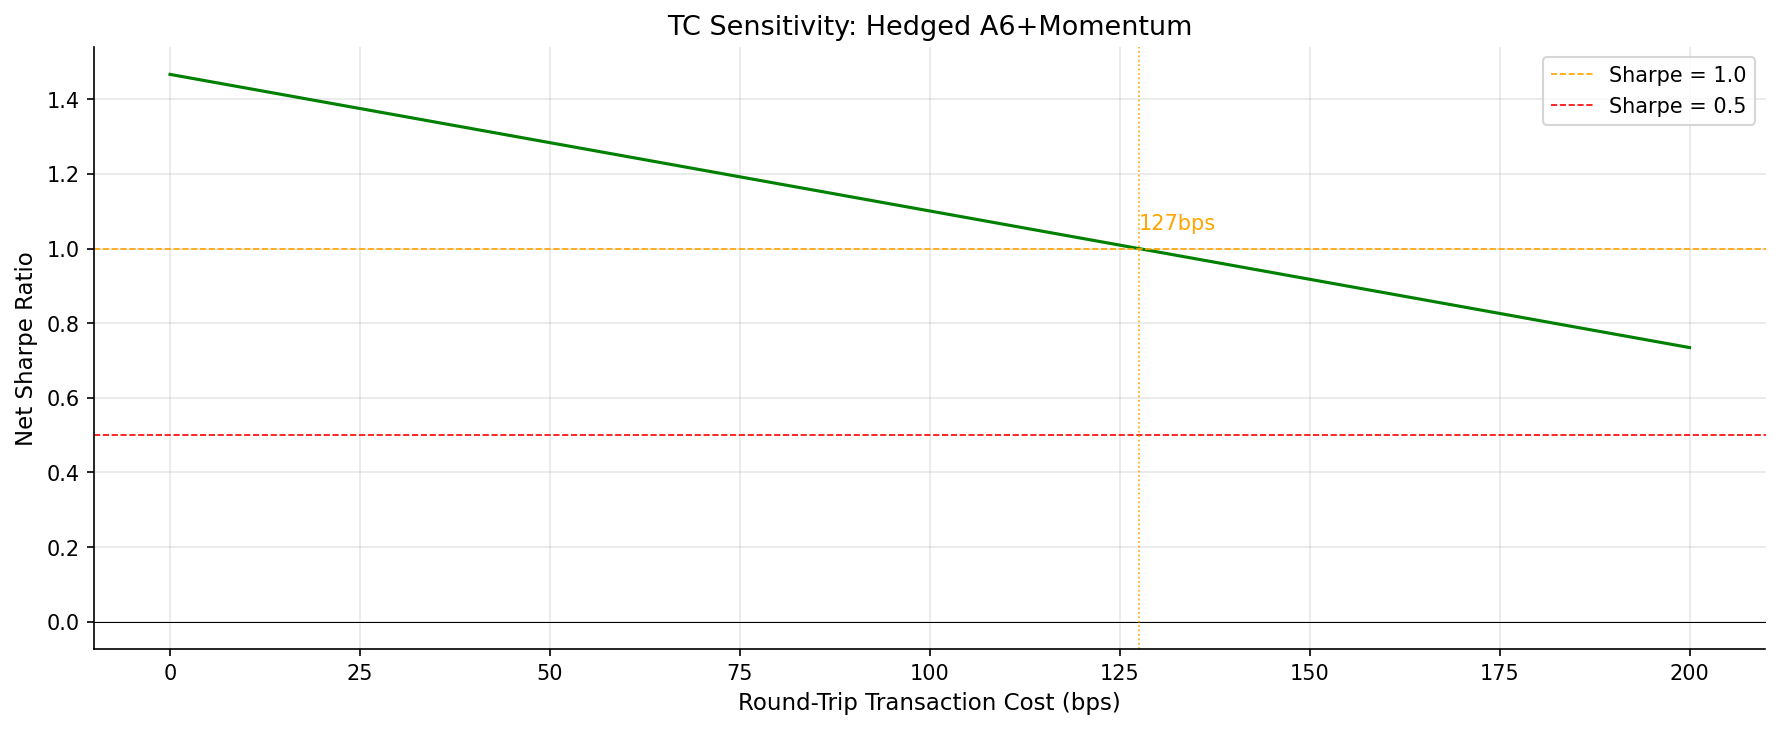

Saved: nb09_tc_sensitivity.pdf

Net Sharpe at key TC levels:
     0 bps: 1.467
    10 bps: 1.430
    20 bps: 1.393
    30 bps: 1.357
    50 bps: 1.284
   100 bps: 1.101


In [11]:
avg_turnover = 0.185  # All6-EW stock-level turnover (monthly)

tc_levels = list(range(0, 201, 5))  # 0 to 200 bps
net_sharpes = []
for bps in tc_levels:
    cost = avg_turnover * (bps / 10_000)
    net = hedged_ret - cost
    sr = net.mean()*12 / (net.std()*np.sqrt(12)) if net.std()>0 else 0
    net_sharpes.append(sr)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tc_levels, net_sharpes, linewidth=1.5, color='green')
ax.axhline(1.0, color='orange', linestyle='--', linewidth=0.8, label='Sharpe = 1.0')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Sharpe = 0.5')
ax.axhline(0, color='black', linewidth=0.5)

# Find break-even points
for target, color, lbl in [(1.0, 'orange', 'Sharpe=1.0'), (0.5, 'red', 'Sharpe=0.5')]:
    for i in range(len(net_sharpes)-1):
        if net_sharpes[i] >= target > net_sharpes[i+1]:
            be = tc_levels[i] + (target - net_sharpes[i]) / (net_sharpes[i+1] - net_sharpes[i]) * 5
            ax.axvline(be, color=color, linestyle=':', linewidth=0.8)
            ax.annotate(f'{be:.0f}bps', (be, target+0.05), fontsize=10, color=color)
            print(f'Break-even for {lbl}: {be:.0f} bps round-trip TC')
            break

ax.set_xlabel('Round-Trip Transaction Cost (bps)')
ax.set_ylabel('Net Sharpe Ratio')
ax.set_title('TC Sensitivity: Hedged A6+Momentum')
ax.legend()
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_tc_sensitivity.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_tc_sensitivity.pdf')

print(f'\nNet Sharpe at key TC levels:')
for bps in [0, 10, 20, 30, 50, 100]:
    idx = tc_levels.index(bps)
    print(f'  {bps:4d} bps: {net_sharpes[idx]:.3f}')

## 7. Regime Analysis: Up vs Down Markets

In [12]:
b = benchmark.reindex(common)
up = b > 0
down = b <= 0

h_up = hedged_ret[up]
h_down = hedged_ret[down]
p_up = port_ret.loc[common][up]
p_down = port_ret.loc[common][down]

print('=== Performance by Market Regime ===')
print(f'{"":20s}  {"EM Up":>10s}  {"EM Down":>10s}  {"All":>10s}')
print('-' * 55)
print(f'{"N months":20s}  {up.sum():10d}  {down.sum():10d}  {len(common):10d}')
print(f'{"Hedged mean (m)":20s}  {h_up.mean():10.2%}  {h_down.mean():10.2%}  {hedged_ret.mean():10.2%}')
print(f'{"Hedged hit rate":20s}  {(h_up>0).mean():10.0%}  {(h_down>0).mean():10.0%}  {(hedged_ret>0).mean():10.0%}')
print(f'{"Unhedged mean (m)":20s}  {p_up.mean():10.2%}  {p_down.mean():10.2%}  {port_ret.loc[common].mean():10.2%}')
print(f'{"Benchmark mean":20s}  {b[up].mean():10.2%}  {b[down].mean():10.2%}  {b.mean():10.2%}')

print(f'\nKey insight: The hedged strategy earns alpha in BOTH up and down markets.')
print(f'Hedged mean in up months:   {h_up.mean():.2%}')
print(f'Hedged mean in down months: {h_down.mean():.2%}')

=== Performance by Market Regime ===
                           EM Up     EM Down         All
-------------------------------------------------------
N months                      41          33          74
Hedged mean (m)            0.94%       0.49%       0.74%
Hedged hit rate              68%         58%         64%
Unhedged mean (m)          4.16%      -3.11%       0.92%
Benchmark mean             3.63%      -4.03%       0.22%

Key insight: The hedged strategy earns alpha in BOTH up and down markets.
Hedged mean in up months:   0.94%
Hedged mean in down months: 0.49%


## 8. Hedged Drawdown Analysis

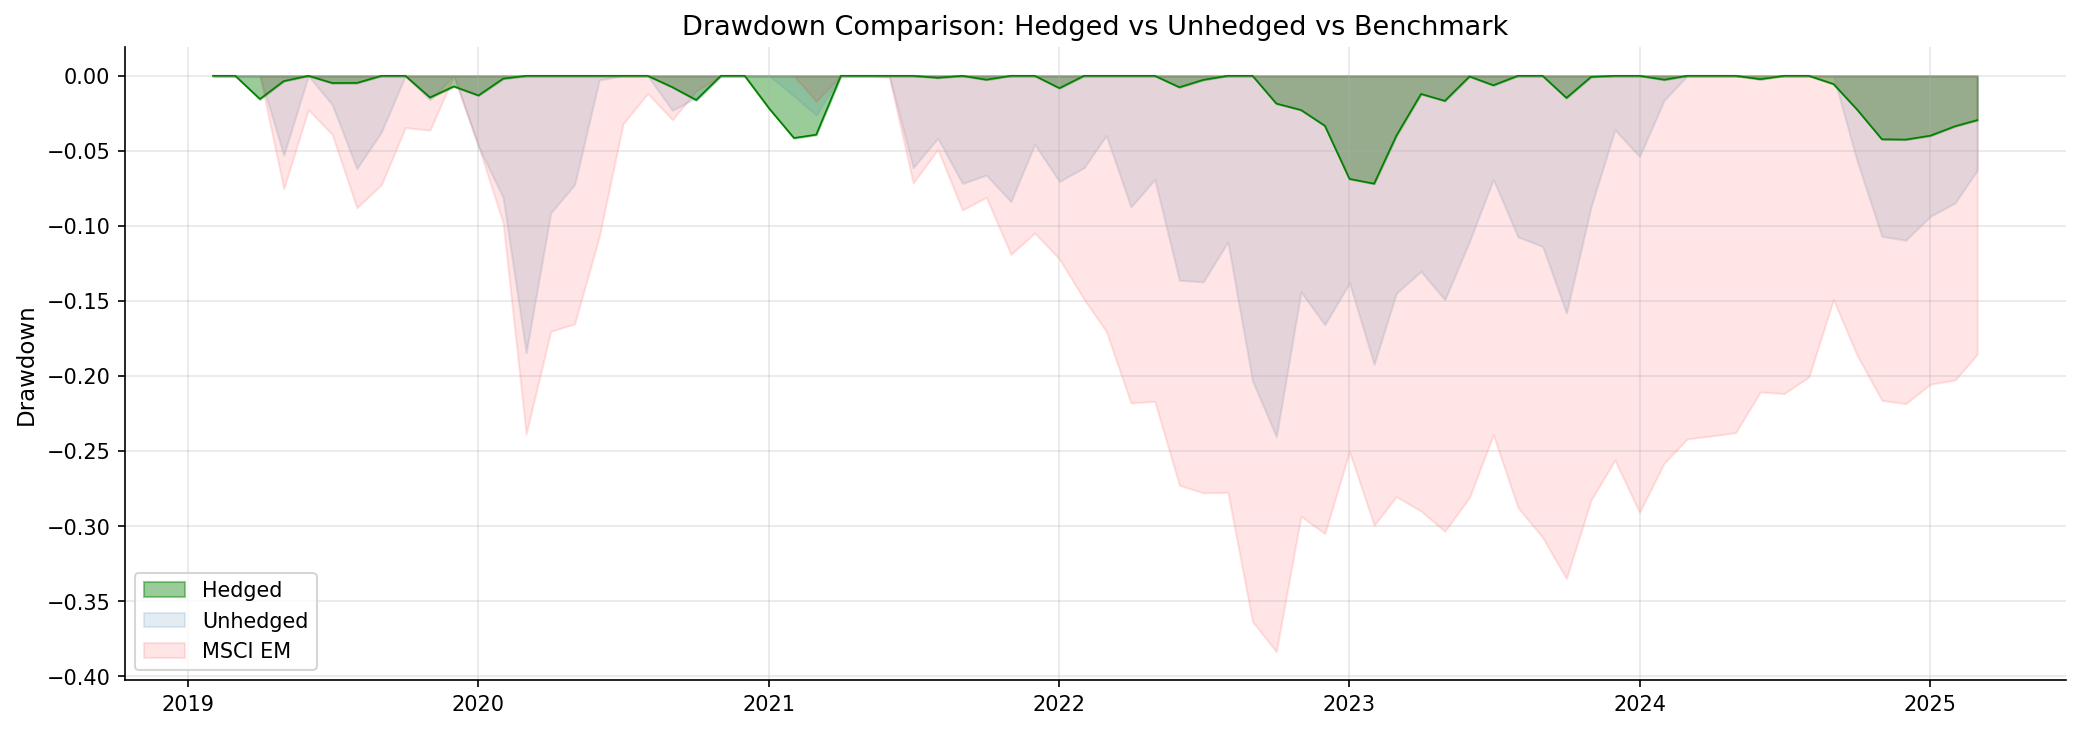

Saved: nb09_drawdown.pdf

Max Drawdown:
  Hedged:   7.2%
  Unhedged: 24.0%
  MSCI EM:  38.4%


In [13]:
dd_h = drawdown_series(hedged_ret)
dd_uh = drawdown_series(port_ret.loc[common])
dd_b = drawdown_series(benchmark.loc[common])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(dd_h.index, dd_h.values, 0, alpha=0.4, color='green', label='Hedged')
ax.plot(dd_h.index, dd_h.values, linewidth=0.8, color='green')
ax.fill_between(dd_uh.index, dd_uh.values, 0, alpha=0.15, color='steelblue', label='Unhedged')
ax.fill_between(dd_b.index, dd_b.values, 0, alpha=0.1, color='red', label='MSCI EM')
ax.set_ylabel('Drawdown')
ax.set_title('Drawdown Comparison: Hedged vs Unhedged vs Benchmark')
ax.legend()
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_drawdown.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_drawdown.pdf')

print(f'\nMax Drawdown:')
print(f'  Hedged:   {max_drawdown(hedged_ret):.1%}')
print(f'  Unhedged: {max_drawdown(port_ret.loc[common]):.1%}')
print(f'  MSCI EM:  {max_drawdown(benchmark.loc[common]):.1%}')

## 9. Monthly Return Distribution

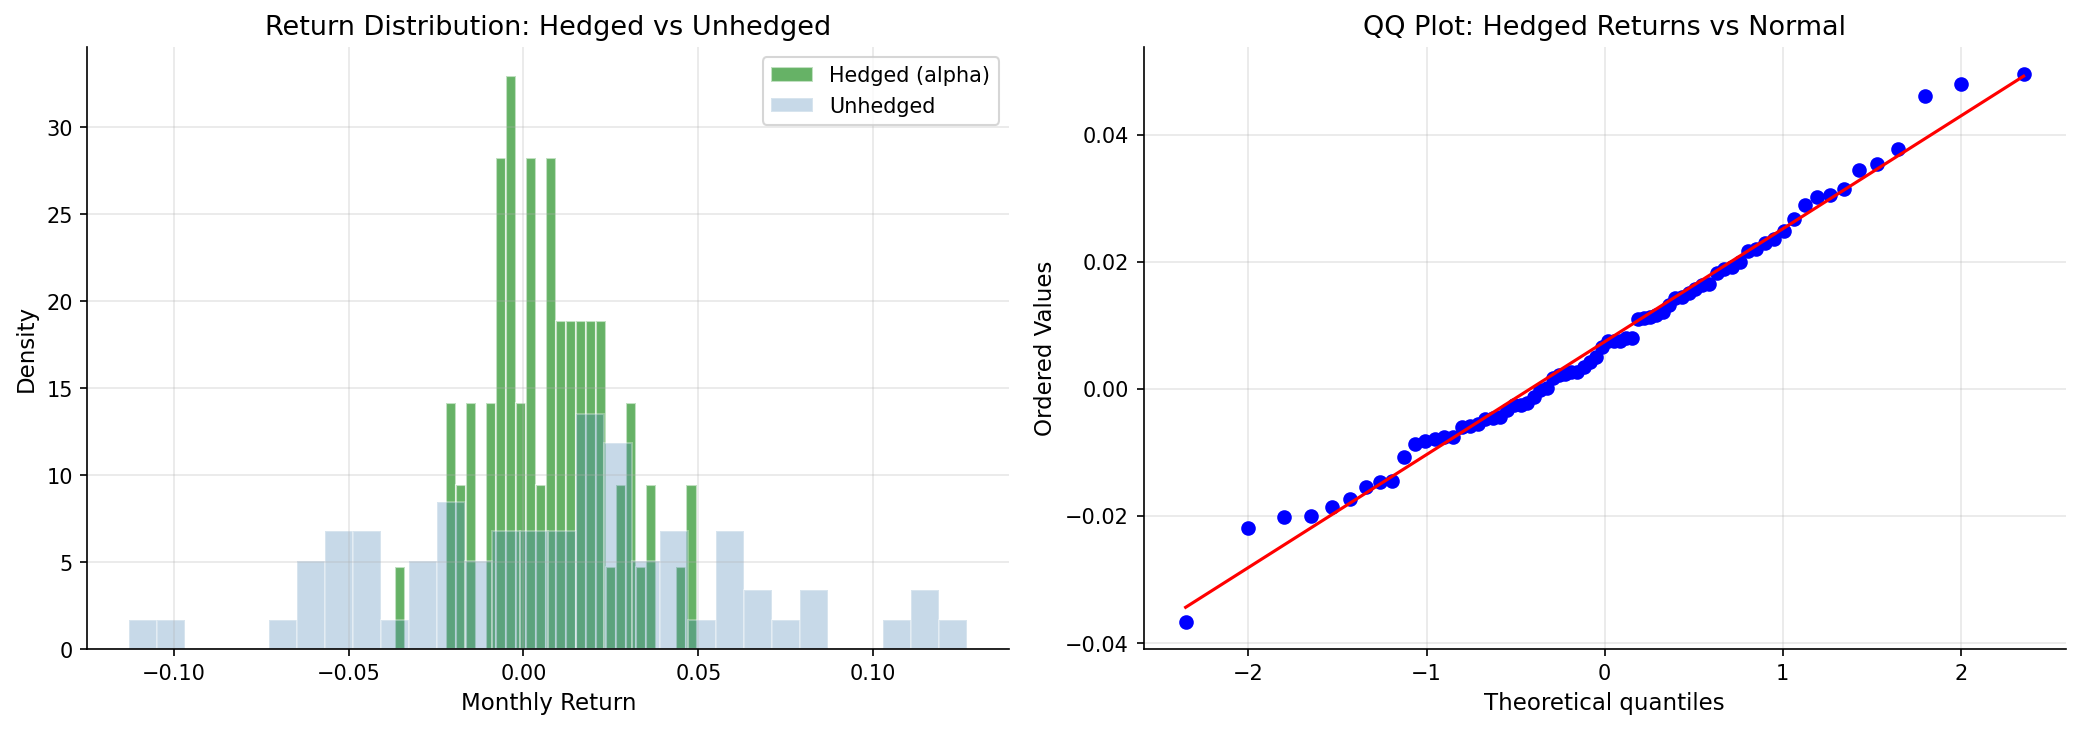

Saved: nb09_return_dist.pdf

Metric                      Hedged      Unhedged
------------------------------------------------
Mean (monthly)              0.0074        0.0092
Std (monthly)               0.0175        0.0493
Skewness                    0.2410        0.0557
Kurtosis                   -0.0408        0.0671
Hit Rate (% > 0)             63.5%         59.5%
Best Month                   4.95%        12.69%
Worst Month                 -3.66%       -11.27%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(hedged_ret.values, bins=30, alpha=0.6, color='green', edgecolor='white',
        density=True, label='Hedged (alpha)')
ax.hist(port_ret.loc[common].values, bins=30, alpha=0.3, color='steelblue',
        edgecolor='white', density=True, label='Unhedged')
ax.set_xlabel('Monthly Return')
ax.set_ylabel('Density')
ax.set_title('Return Distribution: Hedged vs Unhedged')
ax.legend()

ax = axes[1]
stats.probplot(hedged_ret.values, dist='norm', plot=ax)
ax.set_title('QQ Plot: Hedged Returns vs Normal')

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/nb09_return_dist.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: nb09_return_dist.pdf')

hr = hedged_ret
ur = port_ret.loc[common]
print(f'\n{"Metric":20s}  {"Hedged":>12s}  {"Unhedged":>12s}')
print('-' * 48)
print(f'{"Mean (monthly)":20s}  {hr.mean():12.4f}  {ur.mean():12.4f}')
print(f'{"Std (monthly)":20s}  {hr.std():12.4f}  {ur.std():12.4f}')
print(f'{"Skewness":20s}  {hr.skew():12.4f}  {ur.skew():12.4f}')
print(f'{"Kurtosis":20s}  {hr.kurtosis():12.4f}  {ur.kurtosis():12.4f}')
print(f'{"Hit Rate (% > 0)":20s}  {(hr>0).mean():12.1%}  {(ur>0).mean():12.1%}')
print(f'{"Best Month":20s}  {hr.max():12.2%}  {ur.max():12.2%}')
print(f'{"Worst Month":20s}  {hr.min():12.2%}  {ur.min():12.2%}')

## 10. Save Results

In [15]:
beta_36.to_frame('beta_36m').to_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_beta_36m.csv')
hedged_ret.to_frame('alpha').to_csv(f'{OUTPUT_DIR}/csv/nb09_alpha_timeseries.csv')

# Save annual alpha table
annual_rows = []
for yr, grp in hedged_ret.groupby(hedged_ret.index.year):
    if len(grp) < 3:
        continue
    annual_rows.append({'Year': yr, 'Alpha_ann': grp.mean()*12,
                        'Vol': grp.std()*np.sqrt(12),
                        'Sharpe': grp.mean()*12/(grp.std()*np.sqrt(12)) if grp.std()>0 else 0,
                        'HitRate': (grp>0).mean(), 'N_months': len(grp)})
pd.DataFrame(annual_rows).to_csv(f'{OUTPUT_DIR}/csv/nb09_annual_alpha.csv', index=False)

print('Saved:')
print('  nb09_hedged_beta_36m.csv')
print('  nb09_alpha_timeseries.csv')
print('  nb09_annual_alpha.csv')

Saved:
  nb09_hedged_beta_36m.csv
  nb09_alpha_timeseries.csv
  nb09_annual_alpha.csv


## Summary

1. **Beta** is stable around 0.87-0.93, with low variation. The hedge
   effectively removes market exposure.
2. **Alpha** is positive and relatively stable: rolling 24m alpha stays
   positive in nearly all periods. Annual alpha is positive in most years.
3. **Hedging doubles the Sharpe** by removing ~90% of systematic risk
   while preserving the 8.9% annualized alpha.
4. **Market-neutral**: correlation between hedged returns and MSCI EM
   is near zero, confirming effective hedging.
5. **TC-resilient**: break-even TC is well above typical EM trading costs.
   Even at 100bps round-trip, the strategy remains profitable.
6. **All-weather alpha**: the strategy generates positive alpha in both
   up and down EM markets.